<a href="https://colab.research.google.com/github/Jorgellamocca/S2S-PER/blob/main/precipitacion-espacial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# ============================================================
# 1. INSTALAR LIBRERÍAS - GOOGLE COLAB
# ============================================================

!uv pip install -q dynamical-catalog cartopy xarray netcdf4 matplotlib pandas numpy

In [11]:
# ============================================================
# 2. LIBRERÍAS
# ============================================================

import dynamical_catalog

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [12]:
# ============================================================
# 3. ABRIR ECMWF IFS ENS
# 46 días - diario - 1.5°
# ============================================================

CATALOGO = (
    "ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree"
)

print("Abriendo catálogo:")
print(CATALOGO)

ds = dynamical_catalog.open(
    CATALOGO,
    chunks=None
)

print("\nDataset abierto correctamente.")
print(ds)

Abriendo catálogo:
ecmwf-ifs-ens-forecast-46-day-daily-1-5-degree

Dataset abierto correctamente.
<xarray.Dataset> Size: 5TB
Dimensions:                                                (init_time: 265,
                                                            lead_time: 47,
                                                            ensemble_member: 101,
                                                            latitude: 121,
                                                            longitude: 240)
Coordinates:
  * init_time                                              (init_time) datetime64[ns] 2kB ...
  * lead_time                                              (lead_time) timedelta64[us] 376B ...
  * ensemble_member                                        (ensemble_member) int16 202B ...
  * latitude                                               (latitude) float64 968B ...
  * longitude                                              (longitude) float64 2kB ...
    expected_forecast_

In [13]:
# ============================================================
# 4. CONFIGURACIÓN OPERATIVA
# ============================================================

VAR_PREC = "precipitation_surface"

# ------------------------------------------------------------
# Retraso operativo
# ------------------------------------------------------------

RETRASO_DIAS = 2

# ------------------------------------------------------------
# Semanas
# ------------------------------------------------------------

N_SEMANAS = 6
DIAS_SEMANA = 7

# ------------------------------------------------------------
# Dominio Perú
# ------------------------------------------------------------

LON_MIN = -82.5
LON_MAX = -68.0

LAT_MIN = -20.0
LAT_MAX = 1.0


# ------------------------------------------------------------
# Última inicialización disponible
# ------------------------------------------------------------

INIT_TIME = ds.init_time.values[-1]

INIT = pd.Timestamp(INIT_TIME)


print("=" * 80)
print("CONFIGURACIÓN OPERATIVA")
print("=" * 80)

print("Variable             :", VAR_PREC)
print("Última inicialización:", INIT)
print("Retraso operativo    :", RETRASO_DIAS, "días")
print("Miembros             :", ds.sizes["ensemble_member"])
print("Semanas              :", N_SEMANAS)
print("Resolución           : 1.5°")

CONFIGURACIÓN OPERATIVA
Variable             : precipitation_surface
Última inicialización: 2026-09-22 00:00:00
Retraso operativo    : 2 días
Miembros             : 101
Semanas              : 6
Resolución           : 1.5°


In [14]:
# ============================================================
# 5. VENTANA OPERATIVA
# ============================================================

LEAD_INICIO = pd.Timedelta(
    days=RETRASO_DIAS
)

LEAD_FIN = (
    LEAD_INICIO
    +
    pd.Timedelta(
        days=N_SEMANAS * DIAS_SEMANA - 1
    )
)


print("=" * 80)
print("VENTANA OPERATIVA")
print("=" * 80)

print("Inicialización :", INIT)

print(
    "Lead inicial   :",
    LEAD_INICIO
)

print(
    "Lead final     :",
    LEAD_FIN
)

print(
    "Fecha inicial  :",
    INIT + LEAD_INICIO
)

print(
    "Fecha final    :",
    INIT + LEAD_FIN
)

VENTANA OPERATIVA
Inicialización : 2026-09-22 00:00:00
Lead inicial   : 2 days 00:00:00
Lead final     : 43 days 00:00:00
Fecha inicial  : 2026-09-24 00:00:00
Fecha final    : 2026-11-04 00:00:00


In [15]:
# ============================================================
# 6. EXTRAER PRECIPITACIÓN
# ============================================================

prec_rate = ds[VAR_PREC].sel(
    init_time=INIT_TIME
)


# ------------------------------------------------------------
# LONGITUD
# ------------------------------------------------------------

prec_rate = prec_rate.sel(
    longitude=slice(
        LON_MIN,
        LON_MAX
    )
)


# ------------------------------------------------------------
# LATITUD
# ------------------------------------------------------------

if prec_rate.latitude.values[0] > prec_rate.latitude.values[-1]:

    prec_rate = prec_rate.sel(
        latitude=slice(
            LAT_MAX,
            LAT_MIN
        )
    )

else:

    prec_rate = prec_rate.sel(
        latitude=slice(
            LAT_MIN,
            LAT_MAX
        )
    )


# ------------------------------------------------------------
# VENTANA TEMPORAL
# ------------------------------------------------------------

prec_rate = prec_rate.sel(
    lead_time=slice(
        LEAD_INICIO,
        LEAD_FIN
    )
).load()


print("=" * 80)
print("DATOS EXTRAÍDOS")
print("=" * 80)

print(prec_rate)

print("\nDimensiones:")
print(prec_rate.dims)

print("\nShape:")
print(prec_rate.shape)

print("\nUnidad:")
print(prec_rate.attrs.get("units"))

DATOS EXTRAÍDOS
<xarray.DataArray 'precipitation_surface' (lead_time: 42, ensemble_member: 101,
                                           latitude: 14, longitude: 10)> Size: 2MB
array([[[[6.77108765e-05, 4.74452972e-05, 1.29222870e-04, ...,
          1.69754028e-04, 1.14679337e-04, 1.77860260e-04],
         [1.88350677e-05, 2.15768814e-05, 1.23977661e-04, ...,
          1.43349171e-05, 1.87397003e-04, 8.39233398e-05],
         [4.51691449e-07, 2.08616257e-05, 2.95639038e-04, ...,
          2.68220901e-05, 1.38282776e-05, 5.24520874e-06],
         ...,
         [2.25845724e-07, 9.03382897e-08, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [8.13975930e-07, 0.00000000e+00, 0.00000000e+00, ...,
          9.03382897e-08, 4.51691449e-08, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          4.51691449e-08, 0.00000000e+00, 0.00000000e+00]],

        [[3.49044800e-04, 6.72340393e-05, 8.53538513e-05, ...,
          

In [16]:
# ============================================================
# 7. CONTROL DE CALIDAD TEMPORAL
# ============================================================

N_DIAS_ESPERADOS = (
    N_SEMANAS * DIAS_SEMANA
)

N_DIAS_DISPONIBLES = (
    prec_rate.sizes["lead_time"]
)


print("=" * 80)
print("CONTROL TEMPORAL")
print("=" * 80)

print(
    "Días esperados   :",
    N_DIAS_ESPERADOS
)

print(
    "Días disponibles :",
    N_DIAS_DISPONIBLES
)


if N_DIAS_DISPONIBLES < N_DIAS_ESPERADOS:

    raise ValueError(
        "ERROR: No existen suficientes días "
        "para generar las 6 semanas completas."
    )

else:

    print(
        "\nOK: existen datos suficientes "
        "para las 6 semanas."
    )

CONTROL TEMPORAL
Días esperados   : 42
Días disponibles : 42

OK: existen datos suficientes para las 6 semanas.


In [17]:
# ============================================================
# 8. CONVERTIR A mm/día
# ============================================================

SEGUNDOS_DIA = 86400.0

prec_daily = (
    prec_rate
    *
    SEGUNDOS_DIA
)

prec_daily.attrs["units"] = "mm/día"


print("=" * 80)
print("PRECIPITACIÓN DIARIA")
print("=" * 80)

print(
    "Mínimo:",
    float(prec_daily.min()),
    "mm/día"
)

print(
    "Máximo:",
    float(prec_daily.max()),
    "mm/día"
)

PRECIPITACIÓN DIARIA
Mínimo: 0.0 mm/día
Máximo: 214.2333984375 mm/día


In [18]:
# ============================================================
# 9. ACUMULADOS SEMANALES POR MIEMBRO
# ============================================================

semanas = {}

fechas_semanas = {}


print("=" * 90)
print("SEMANAS OPERATIVAS")
print("=" * 90)


for semana in range(
    1,
    N_SEMANAS + 1
):

    i0 = (
        (semana - 1)
        *
        DIAS_SEMANA
    )

    i1 = (
        i0
        +
        DIAS_SEMANA
    )


    # --------------------------------------------------------
    # 7 días
    # --------------------------------------------------------

    datos_semana = prec_daily.isel(
        lead_time=slice(
            i0,
            i1
        )
    )


    # --------------------------------------------------------
    # Verificación
    # --------------------------------------------------------

    if datos_semana.sizes["lead_time"] != 7:

        raise ValueError(
            f"Semana {semana} "
            "no contiene exactamente 7 días."
        )


    # --------------------------------------------------------
    # Acumulado semanal por miembro
    # --------------------------------------------------------

    acumulado = datos_semana.sum(
        dim="lead_time"
    )


    semanas[semana] = acumulado


    # --------------------------------------------------------
    # Fechas
    # --------------------------------------------------------

    fechas = pd.to_datetime(
        datos_semana.valid_time.values
    )


    fechas_semanas[semana] = (
        fechas[0],
        fechas[-1]
    )


    print(
        f"Semana {semana}: "
        f"{fechas[0]:%d-%m-%Y} "
        f"al "
        f"{fechas[-1]:%d-%m-%Y}"
    )

SEMANAS OPERATIVAS
Semana 1: 24-09-2026 al 30-09-2026
Semana 2: 01-10-2026 al 07-10-2026
Semana 3: 08-10-2026 al 14-10-2026
Semana 4: 15-10-2026 al 21-10-2026
Semana 5: 22-10-2026 al 28-10-2026
Semana 6: 29-10-2026 al 04-11-2026


In [19]:
# ============================================================
# 10. ESTADÍSTICOS DEL ENSAMBLE
# ============================================================

resultados = {}


for semana in range(
    1,
    N_SEMANAS + 1
):

    pp = semanas[semana]


    media = pp.mean(
        dim="ensemble_member"
    )


    p10 = pp.quantile(
        0.10,
        dim="ensemble_member"
    )


    p50 = pp.quantile(
        0.50,
        dim="ensemble_member"
    )


    p90 = pp.quantile(
        0.90,
        dim="ensemble_member"
    )


    dispersion = (
        p90
        -
        p10
    )


    resultados[semana] = {

        "media": media,

        "p10": p10,

        "p50": p50,

        "p90": p90,

        "dispersion": dispersion

    }


print(
    "Estadísticos calculados correctamente."
)

Estadísticos calculados correctamente.


In [20]:
# ============================================================
# 11. PROBABILIDADES
# ============================================================

UMBRALES = [
    10,
    25,
    50,
    100
]


probabilidades = {}


for semana in range(
    1,
    N_SEMANAS + 1
):

    pp = semanas[semana]

    probabilidades[semana] = {}


    for umbral in UMBRALES:

        prob = (
            (pp >= umbral)
            .mean(
                dim="ensemble_member"
            )
            *
            100.0
        )


        probabilidades[semana][umbral] = prob


print(
    "Probabilidades calculadas correctamente."
)

Probabilidades calculadas correctamente.


/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:263: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


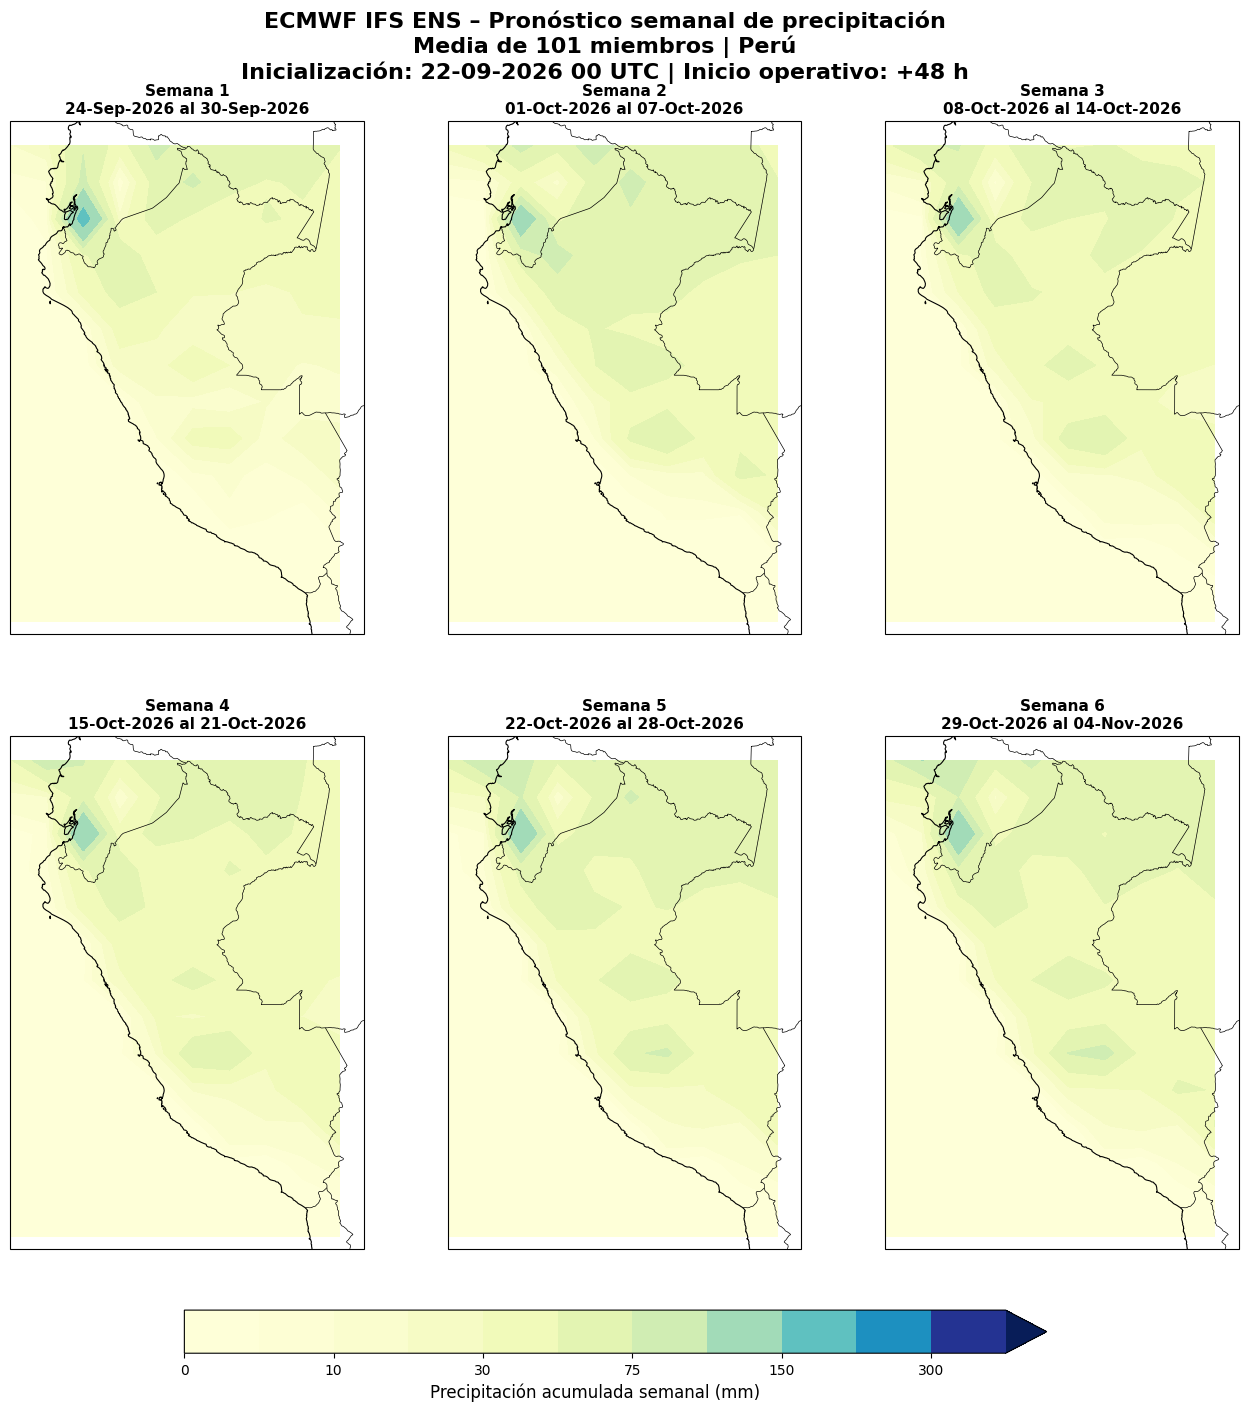

In [21]:
# ============================================================
# 12. MAPA
# PRECIPITACIÓN MEDIA SEMANAL
# ============================================================

niveles_pp = [
    0,
    5,
    10,
    20,
    30,
    50,
    75,
    100,
    150,
    200,
    300,
    400
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 16),
    subplot_kw={
        "projection":
            ccrs.PlateCarree()
    }
)


axes = axes.ravel()


for i, semana in enumerate(
    range(1, N_SEMANAS + 1)
):

    ax = axes[i]

    campo = (
        resultados[semana]["media"]
    )


    cf = ax.contourf(
        campo.longitude,
        campo.latitude,
        campo,
        levels=niveles_pp,
        cmap="YlGnBu",
        extend="max",
        transform=ccrs.PlateCarree()
    )


    # --------------------------------------------------------
    # MAPA
    # --------------------------------------------------------

    ax.coastlines(
        resolution="10m",
        linewidth=0.8
    )


    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5
    )


    ax.set_extent(
        [
            LON_MIN,
            LON_MAX,
            LAT_MIN,
            LAT_MAX
        ],
        crs=ccrs.PlateCarree()
    )


    # --------------------------------------------------------
    # FECHAS
    # --------------------------------------------------------

    fecha_ini, fecha_fin = (
        fechas_semanas[semana]
    )


    ax.set_title(
        f"Semana {semana}\n"
        f"{fecha_ini:%d-%b-%Y} "
        f"al "
        f"{fecha_fin:%d-%b-%Y}",
        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# BARRA DE COLOR
# ============================================================

cbar = fig.colorbar(
    cf,
    ax=axes.tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.05
)


cbar.set_label(
    "Precipitación acumulada semanal (mm)",
    fontsize=12
)


fig.suptitle(
    "ECMWF IFS ENS – Pronóstico semanal de precipitación\n"
    "Media de 101 miembros | Perú\n"
    f"Inicialización: "
    f"{INIT:%d-%m-%Y %H UTC} | "
    f"Inicio operativo: +{RETRASO_DIAS * 24} h",
    fontsize=16,
    fontweight="bold",
    y=0.95
)


plt.show()

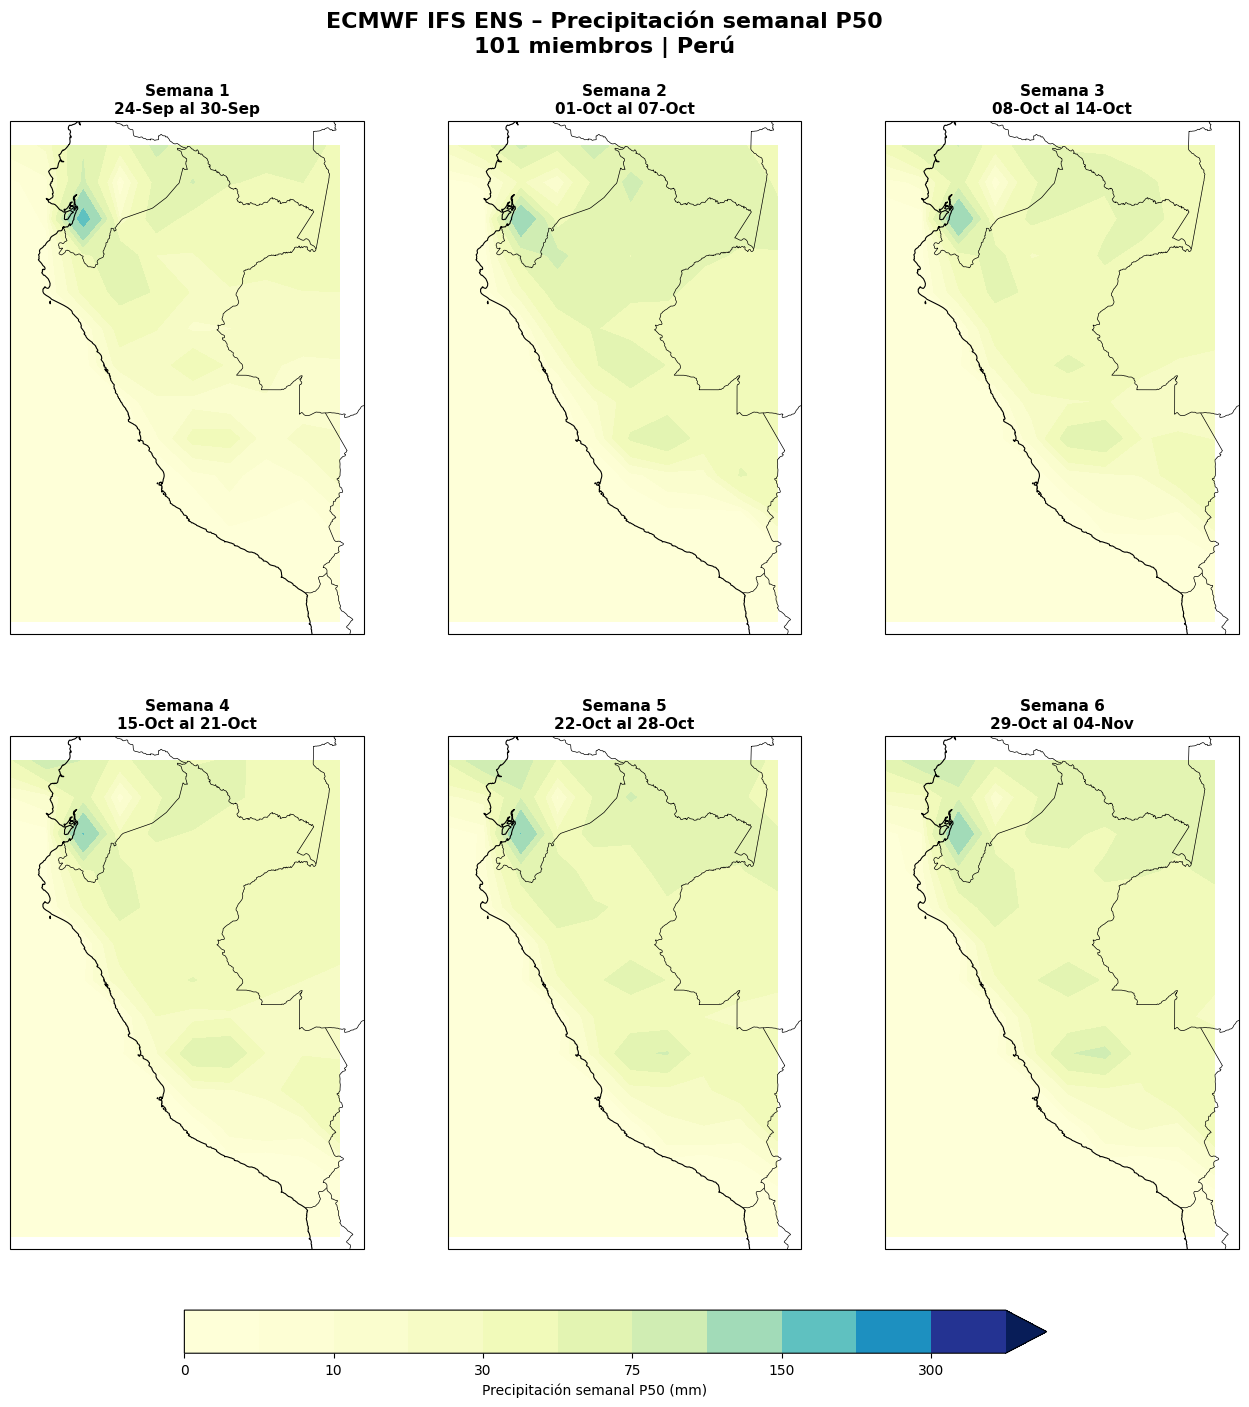

In [22]:
# ============================================================
# 13. MAPA P50
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 16),
    subplot_kw={
        "projection":
            ccrs.PlateCarree()
    }
)

axes = axes.ravel()


for i, semana in enumerate(
    range(1, N_SEMANAS + 1)
):

    ax = axes[i]

    campo = (
        resultados[semana]["p50"]
    )


    cf = ax.contourf(
        campo.longitude,
        campo.latitude,
        campo,
        levels=niveles_pp,
        cmap="YlGnBu",
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax.coastlines(
        resolution="10m",
        linewidth=0.8
    )


    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5
    )


    ax.set_extent(
        [
            LON_MIN,
            LON_MAX,
            LAT_MIN,
            LAT_MAX
        ]
    )


    fecha_ini, fecha_fin = (
        fechas_semanas[semana]
    )


    ax.set_title(
        f"Semana {semana}\n"
        f"{fecha_ini:%d-%b} "
        f"al "
        f"{fecha_fin:%d-%b}",
        fontsize=11,
        fontweight="bold"
    )


cbar = fig.colorbar(
    cf,
    ax=axes.tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.05
)


cbar.set_label(
    "Precipitación semanal P50 (mm)"
)


fig.suptitle(
    "ECMWF IFS ENS – Precipitación semanal P50\n"
    "101 miembros | Perú",
    fontsize=16,
    fontweight="bold",
    y=0.95
)


plt.show()

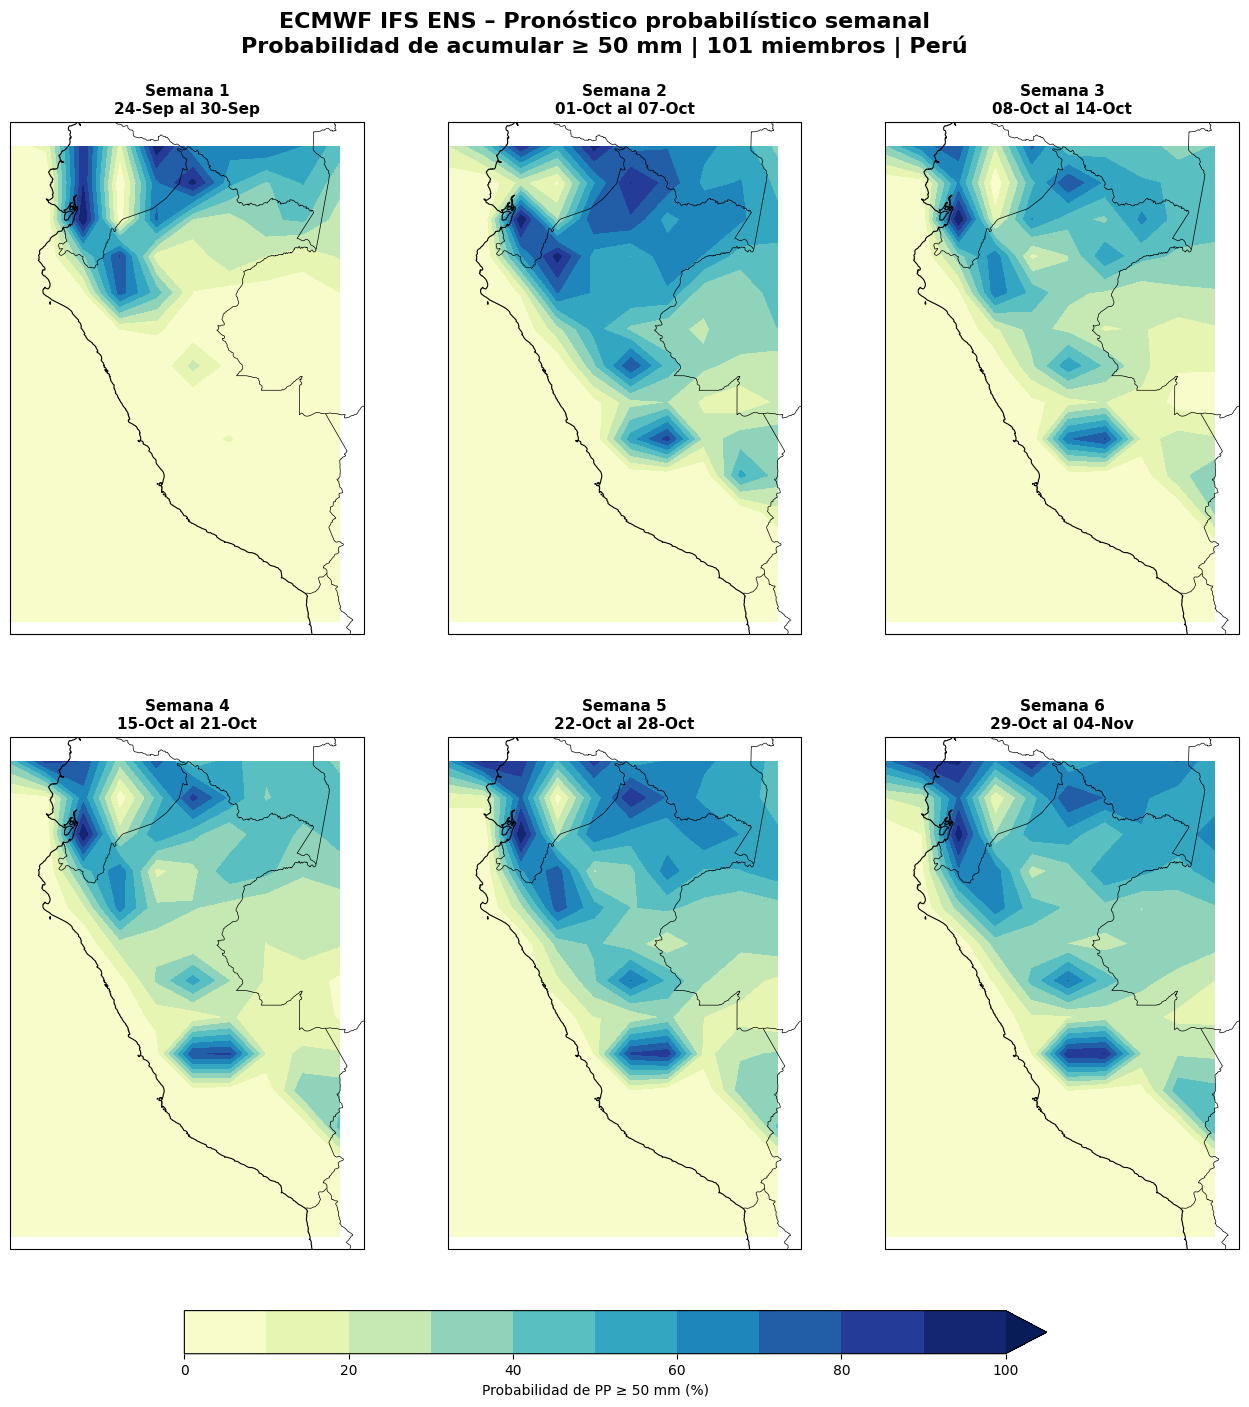

In [23]:
# ============================================================
# 14. MAPA PROBABILÍSTICO
# Probabilidad PP >= 50 mm/semana
# ============================================================

UMBRAL_MAPA = 50


niveles_prob = np.arange(
    0,
    110,
    10
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 16),
    subplot_kw={
        "projection":
            ccrs.PlateCarree()
    }
)


axes = axes.ravel()


for i, semana in enumerate(
    range(1, N_SEMANAS + 1)
):

    ax = axes[i]


    campo = (
        probabilidades[semana]
        [UMBRAL_MAPA]
    )


    cf = ax.contourf(
        campo.longitude,
        campo.latitude,
        campo,
        levels=niveles_prob,
        cmap="YlGnBu",
        extend="max",
        transform=ccrs.PlateCarree()
    )


    ax.coastlines(
        resolution="10m",
        linewidth=0.8
    )


    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5
    )


    ax.set_extent(
        [
            LON_MIN,
            LON_MAX,
            LAT_MIN,
            LAT_MAX
        ]
    )


    fecha_ini, fecha_fin = (
        fechas_semanas[semana]
    )


    ax.set_title(
        f"Semana {semana}\n"
        f"{fecha_ini:%d-%b} "
        f"al "
        f"{fecha_fin:%d-%b}",
        fontsize=11,
        fontweight="bold"
    )


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    cf,
    ax=axes.tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.05
)


cbar.set_label(
    f"Probabilidad de PP ≥ "
    f"{UMBRAL_MAPA} mm (%)"
)


fig.suptitle(
    "ECMWF IFS ENS – Pronóstico probabilístico semanal\n"
    f"Probabilidad de acumular ≥ "
    f"{UMBRAL_MAPA} mm | "
    "101 miembros | Perú",
    fontsize=16,
    fontweight="bold",
    y=0.95
)


plt.show()

In [24]:
# ============================================================
# REVISAR VARIABLES DISPONIBLES
# ============================================================

for var in ds.data_vars:
    print(
        f"{var:45s} | "
        f"{ds[var].attrs.get('long_name', ''):60s} | "
        f"{ds[var].attrs.get('units', '')}"
    )

average_convective_available_potential_energy_surface | Convective available potential energy                        | J kg-1
average_temperature_2m                        | Mean temperature at 2 metres in the last 24 hours            | degree_Celsius
downward_sensible_heat_flux_surface           | Time-mean surface sensible heat flux                         | W m-2
downward_latent_heat_flux_surface             | Time-mean surface latent heat flux                           | W m-2
downward_long_wave_radiation_flux_surface     | Surface downward long-wave radiation flux                    | W m-2
eastward_turbulent_surface_stress             | Time-mean eastward turbulent surface stress                  | Pa
average_dew_point_temperature_2m              | Mean 2 metre dewpoint temperature in the last 24 hours       | degree_Celsius
downward_short_wave_radiation_flux_surface    | Surface downward short-wave radiation flux                   | W m-2
minimum_temperature_2m                  